##**Anomaly detection**

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.spatial.distance import cdist

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,f1_score,classification_report,accuracy_score,recall_score,auc
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import MinMaxScaler

In [4]:
folder_path = "/content/drive/MyDrive/Detector_Anomaly_Result"

#**Exploratory Data Analysis**

In [5]:
ohlc_data = pd.read_csv(f"{folder_path}/Ohlc_dataset.csv",parse_dates=["Timestamp"])

In [6]:
df1=ohlc_data.copy()

In [7]:
df1.rename(columns = {"open":"Open","high":"High","low":"Low","close":"Close"},inplace = True)

In [8]:
df1.drop("Timestamp", axis =1)

,Open,Close,High,Low
0,11294.48,11263.29,11303.90,11231.24
1,11266.16,11253.22,11270.96,11236.71
2,11249.29,11141.98,11258.47,11124.43
3,11141.42,11181.35,11184.51,11124.76
4,11181.45,11118.63,11195.20,11111.91
...,...,...,...,...
284655,101306.88,101755.28,101852.54,101277.61
284656,101747.80,101904.87,102014.40,101632.27
284657,101895.78,102207.64,102341.14,101586.56
284658,102202.51,101950.41,102249.47,101715.18


##**Method 1: Sampling-based distance outlier detection**

In [9]:
close_prices = df1['Close'].values  # Extract the close prices as a 1D array

# Parameters
window_size = 300  # Size of the sliding window
sample_size = 40   # Size of the sample
threshold_percentile = 95
outliers = []
window_filled = False


window = np.full(window_size, np.nan)
sample = np.zeros(sample_size)


In [10]:
def update_window(window_new):
  window = new_point
  return window

In [11]:
def update_sample(window, sample_size):
    """Sample more recent prices with higher probability."""
    valid_values = window[~np.isnan(window)]
    if len(valid_values) < sample_size:
        return valid_values  # Return available data if insufficient

    # Generate weights (exponential decay)
    weights = np.exp(np.linspace(-1, 0, len(valid_values)))
    weights /= weights.sum()  # Normalize to sum to 1

    return np.random.choice(valid_values, sample_size, replace=False, p=weights)


In [12]:
def check_anomaly(new_point):
    """Detect outliers in real-time for HFT."""
    global window, sample, outliers, window_filled

    window = update_window(new_point)

    if not window_filled and not np.isnan(window).any():
        window_filled = True
        print("Window is fully populated. Anomaly detection is now active.")

    if not window_filled:
        return None

    sample = update_sample(window, sample_size)

    min_distances = np.abs(window[:, None] - sample).min(axis=1)

    threshold = np.percentile(min_distances, threshold_percentile)

    # Detect outlier
    if min_distances[-1] > threshold:
        outliers.append((len(outliers), new_point))
        alert_msg = f"Outlier Detected! Price = {min_distances[-1]}"
        print (alert_msg)
        return new_point

    return None

In [13]:
n = len(close_prices)
for i in range(0, n - window_size + 1):
    new_point  = close_prices[i:i + window_size]
    check_anomaly(new_point)

Streaming output truncated to the last 5000 lines.
Outlier Detected! Price = 1063.5100000000093
Outlier Detected! Price = 1670.6199999999953
Outlier Detected! Price = 1454.390000000014
Outlier Detected! Price = 1269.8699999999953
Outlier Detected! Price = 1898.0
Outlier Detected! Price = 2000.329999999958
Outlier Detected! Price = 1471.7600000000093
Outlier Detected! Price = 818.7999999999884
Outlier Detected! Price = 1348.109999999986
Outlier Detected! Price = 734.0299999999988
Outlier Detected! Price = 1438.6600000000035
Outlier Detected! Price = 553.4099999999744
Outlier Detected! Price = 386.6900000000023
Outlier Detected! Price = 953.2600000000093
Outlier Detected! Price = 839.4400000000023
Outlier Detected! Price = 3044.259999999951
Outlier Detected! Price = 4535.640000000014
Outlier Detected! Price = 5788.98000000004
Outlier Detected! Price = 460.54999999998836
Outlier Detected! Price = 4207.72000000003
Outlier Detected! Price = 4245.610000000044
Outlier Detected! Price = 4870.3

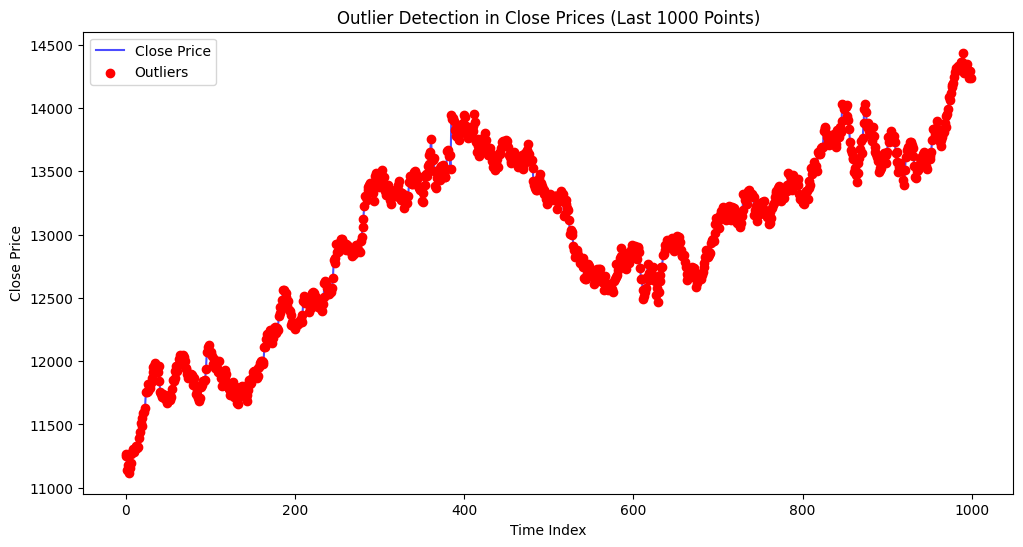

In [14]:
# Visualization for the last 1000 points
if outliers:
    # Extract outlier indices and values
    outlier_indices = [idx for idx, _ in outliers]
    outlier_values = [val for _, val in outliers]

    # Filter for the last 1000 points
    last_1000_indices = outlier_indices[:1000]
    last_1000_close_prices = close_prices[:1000]

    # Find outliers within the last 1000 points
    last_1000_outlier_indices = [idx for idx in outlier_indices if idx in last_1000_indices]
    last_1000_outlier_values = [close_prices[idx] for idx in last_1000_outlier_indices]

    # Plot the last 1000 close prices
    plt.figure(figsize=(12, 6))
    plt.plot(last_1000_indices, last_1000_close_prices, label='Close Price', color='blue', alpha=0.7)

    # Highlight outliers within the last 1000 points
    if last_1000_outlier_indices:
        plt.scatter(last_1000_outlier_indices, last_1000_outlier_values, color='red', label='Outliers', zorder=5)

    # Add labels and legend
    plt.title('Outlier Detection in Close Prices (Last 1000 Points)')
    plt.xlabel('Time Index')
    plt.ylabel('Close Price')
    plt.legend()
    plt.show()
else:
    print("No outliers detected.")

In [15]:
len(outliers)

26087

##**Method 2: Isolation Forest**

###**Exploratory Data Analysis**

In [13]:
# Check for missing values

ohlc_data.isnull().sum()

,0
Timestamp,0
open,0
close,0
high,0
low,0


In [14]:
ohlc_data.dtypes

,0
Timestamp,datetime64[ns]
open,float64
close,float64
high,float64
low,float64


In [15]:
# Check for correlation
corr = ohlc_data.drop("Timestamp", axis =1).corr()

<Axes: >

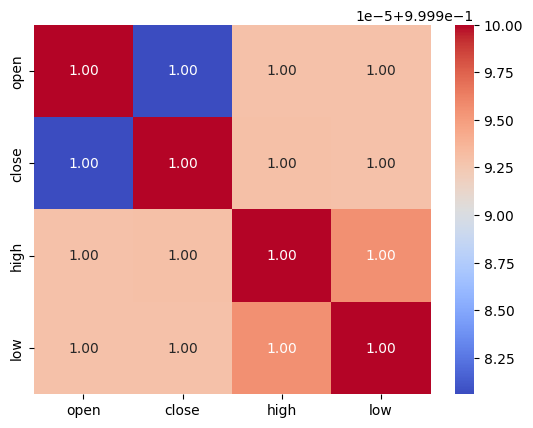

In [16]:
sns.heatmap(corr,annot =True, fmt = ".2f", cmap= "coolwarm")

###**Feature Engineering**

In [17]:
# Feature Engineering

def ATR(df):
  df['tr1'] = df['high'] - df['low']
  df['tr2'] = abs(df['high'] - df['close'].shift(1))
  df['tr3'] = abs(df['low'] - df['close'].shift(1))
  df['true_range'] = df[['tr1', 'tr2', 'tr3']].max(axis=1)
  return (df['true_range'].rolling(window=14).mean())


def Bollinger_Bands(df, win):
  df['MA20'] = df['close'].rolling(window=win).mean()
  df['STD20'] = df['close'].rolling(window=win).std()
  df['UpperBB'] = df['MA20'] + (df['STD20'] * 2)
  df['LowerBB'] = df['MA20'] - (df['STD20'] * 2)
  return ((df['UpperBB'] - df['LowerBB']) / df['MA20'])

# Compute RSI (Relative Strength Index)
def compute_rsi(series, period=14):
    delta = series.diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def datetime_convert(data):
  data['Timestamp'] = pd.to_datetime(data['Timestamp'])
  data['Hour'] = data['Timestamp'].dt.hour
  data['DayOfWeek'] = data['Timestamp'].dt.dayofweek
  data['Month'] = data['Timestamp'].dt.month
  data['IsWeekend'] = data['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
  return data

In [18]:
df = ohlc_data.copy()

In [19]:
df['ATR'] = ATR(df)
df['RSI'] = compute_rsi(df['close'])
df['BB_Width']  = Bollinger_Bands(df,20)
df['Returns'] = df['close'].pct_change()
datetime_convert(df)

,Timestamp,open,close,high,low,tr1,tr2,tr3,true_range,ATR,...,MA20,STD20,UpperBB,LowerBB,BB_Width,Returns,Hour,DayOfWeek,Month,IsWeekend
0,2016-08-22 23:45:00,11294.48,11263.29,11303.90,11231.24,72.66,NaN,NaN,72.66,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,23,0,8,0
1,2016-08-23 00:00:00,11266.16,11253.22,11270.96,11236.71,34.25,7.67,26.58,34.25,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.000894,0,1,8,0
2,2016-08-23 00:15:00,11249.29,11141.98,11258.47,11124.43,134.04,5.25,128.79,134.04,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.009885,0,1,8,0
3,2016-08-23 00:30:00,11141.42,11181.35,11184.51,11124.76,59.75,42.53,17.22,59.75,NaN,...,NaN,NaN,NaN,NaN,NaN,0.003533,0,1,8,0
4,2016-08-23 00:45:00,11181.45,11118.63,11195.20,11111.91,83.29,13.85,69.44,83.29,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.005609,0,1,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284655,2024-10-08 22:30:00,101306.88,101755.28,101852.54,101277.61,574.93,559.74,15.19,574.93,566.514286,...,102156.471,1332.543918,104821.558836,99491.383164,0.052177,0.004566,22,1,10,0
284656,2024-10-08 22:45:00,101747.80,101904.87,102014.40,101632.27,382.13,259.12,123.01,382.13,529.150000,...,102011.899,1179.079133,104370.057266,99653.740734,0.046233,0.001470,22,1,10,0
284657,2024-10-08 23:00:00,101895.78,102207.64,102341.14,101586.56,754.58,436.27,318.31,754.58,540.162857,...,101901.687,1037.451241,103976.589482,99826.784518,0.040724,0.002971,23,1,10,0
284658,2024-10-08 23:15:00,102202.51,101950.41,102249.47,101715.18,534.29,41.83,492.46,534.29,542.015714,...,101776.070,845.344343,103466.758685,100085.381315,0.033224,-0.002517,23,1,10,0


###**Decomposition of the time series**

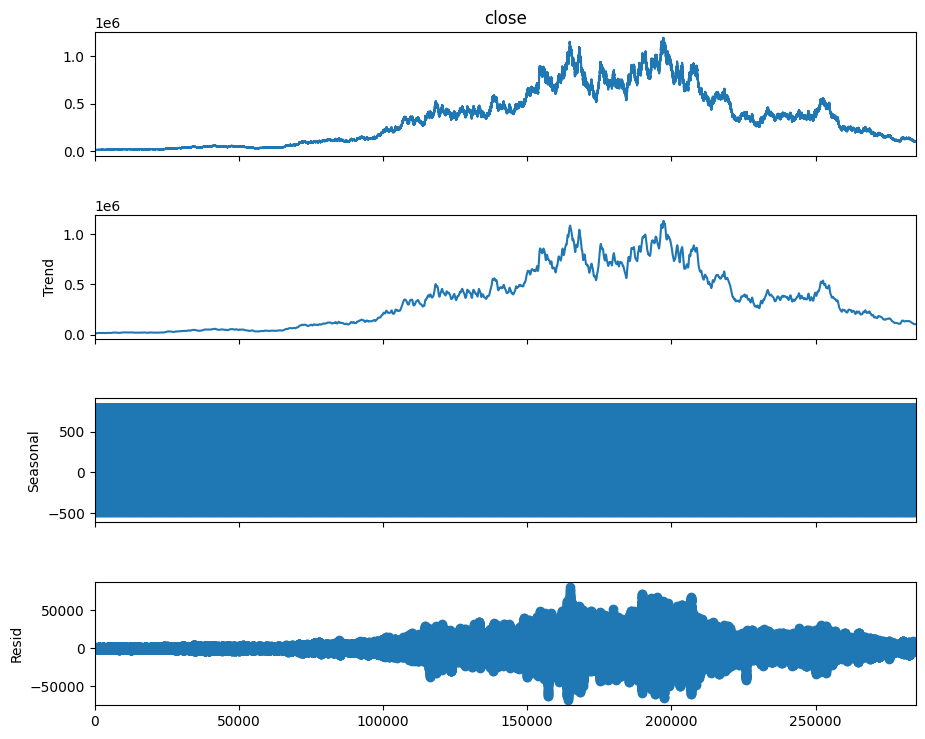

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Decompose the time series
decomposition = seasonal_decompose(df['close'], model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.show()



1.  The trend is strong, the data is likely non-stationary.
2.  Residuals capture unexplained variations
3.  The seasonal component appears noisy and unclear, which might suggest that there is little to no seasonality in the data.
4.  The residuals appear heteroscedastic (i.e., increasing variance over time), meaning that volatility changes significantly. These might indicate unusual price movements or market anomalies.


**Action point:**
1. The trend and residuals will be added and used as features for anomaly detection



In [21]:
df['Trend'] = decomposition.trend
df['Residual'] = decomposition.resid

In [22]:
feature_cols = ['open','high','low','close','ATR', 'BB_Width', 'RSI', 'Returns','Hour', 'DayOfWeek','Month','IsWeekend','Trend','Residual']

In [23]:
df[feature_cols].bfill(inplace = True)

/tmp/ipython-input-23-1656285281.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[feature_cols].bfill(inplace = True)


In [24]:
df2 = df[feature_cols].copy()

###**Isolation Forest Modelling**



```
Isolation forest detect anomaly by flagging data point with least average path length as an anomaly.
```



In [25]:
def rolling_zscore_df(df, window=30):

    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns  # Select only numeric columns

    if window is None:  # If window is not specified, use the entire dataset
        mean = df[numeric_cols].mean()
        std = df[numeric_cols].std()
    else:
        mean = df[numeric_cols].rolling(window=window, min_periods=1).mean()
        std = df[numeric_cols].rolling(window=window, min_periods=1).std()

    return df.assign(**{col: (df[col] - mean[col]) / (std[col] + 1e-8) for col in numeric_cols})

In [26]:
df2 = rolling_zscore_df(df2, window=30)

In [27]:
df2.fillna(0,inplace = True)

In [28]:
# Train the Isolation Forest model
isolation_forest = IsolationForest(n_estimators=100,contamination=0.05, random_state =0)

In [29]:
df2['Anomaly_Score'] = isolation_forest.fit_predict(df2)

In [30]:
df2

,open,high,low,close,ATR,BB_Width,RSI,Returns,Hour,DayOfWeek,Month,IsWeekend,Trend,Residual,Anomaly_Score
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23,0,8,0.0,0.0,0.0,1
1,-0.707107,-0.707107,0.707107,-0.707107,0.000000,0.000000,0.000000,0.000000,0,1,8,0.0,0.0,0.0,1
2,-0.905900,-0.822625,-1.153622,-1.151466,0.000000,0.000000,0.000000,-0.707106,0,1,8,0.0,0.0,0.0,1
3,-1.440617,-1.387427,-0.862871,-0.491735,0.000000,0.000000,0.000000,0.870022,0,1,8,0.0,0.0,0.0,1
4,-0.713661,-0.928185,-0.862800,-1.126455,0.000000,0.000000,0.000000,-0.412553,0,1,8,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284655,-1.086428,-0.922204,-0.921897,-0.772328,-1.049841,0.932601,0.440191,1.884039,22,1,10,0.0,0.0,0.0,1
284656,-0.775627,-0.772029,-0.663362,-0.633662,-1.602181,0.575121,0.715946,0.848432,22,1,10,0.0,0.0,0.0,1
284657,-0.637665,-0.530275,-0.639357,-0.407734,-1.353271,0.247342,1.301391,1.255338,23,1,10,0.0,0.0,0.0,1
284658,-0.409320,-0.537329,-0.514736,-0.518854,-1.275996,-0.186280,1.219142,-0.546642,23,1,10,0.0,0.0,0.0,1


In [31]:
df2['Decision_Score'] = isolation_forest.decision_function(df2[feature_cols])

In [32]:
df2['Anomaly'] = df2['Anomaly_Score'].apply(lambda x: 1 if x == -1 else 0)

In [33]:
df2[['close','Decision_Score','Anomaly_Score','Anomaly']][df2['Anomaly'] == 1]

,close,Decision_Score,Anomaly_Score,Anomaly
246,3.101886,-0.008768,-1,1
249,2.901841,-0.021496,-1,1
281,3.353783,-0.029857,-1,1
282,3.547124,-0.034054,-1,1
283,3.362779,-0.032410,-1,1
...,...,...,...,...
284641,-3.183220,-0.037703,-1,1
284642,-2.865919,-0.024723,-1,1
284643,-2.876841,-0.027947,-1,1
284644,-2.600489,-0.016348,-1,1


In [34]:
df2['Anomaly'].value_counts()

,count
Anomaly,
0,270427
1,14233


In [35]:
def anomaly_image(data):
  # Separate anomalies and normal points
  anomalies = data[data['Anomaly'] == 1]
  normal_points = data[data['Anomaly'] == 0]

  # Plot the Close price and anomalies
  plt.figure(figsize=(14, 8))
  plt.plot(data.index, data['close'], label='Close Price', color='blue', linewidth=0.7)
  plt.scatter(anomalies.index, anomalies['close'], color='red', label='Anomalies', zorder=5)
  plt.title('Anomaly Detection with Isolation Forest')
  plt.xlabel('Time')
  plt.ylabel('Close Price')
  plt.legend()
  plt.show()


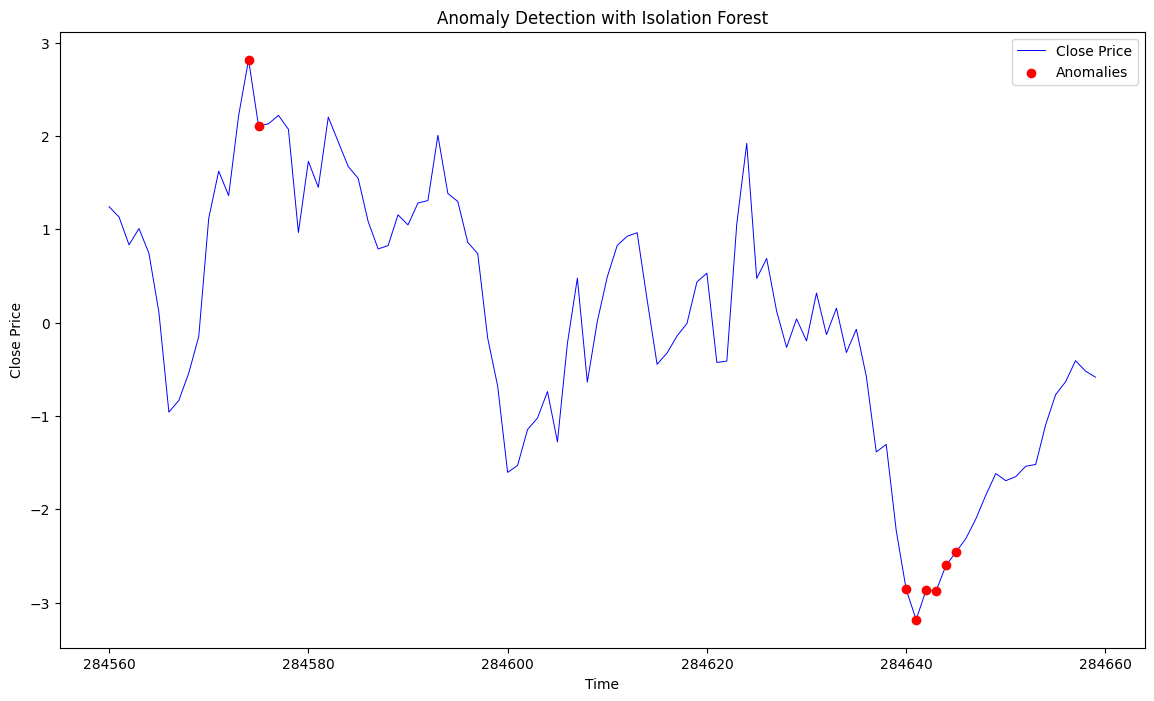

In [36]:
anomaly_image(df2[-100:])

####Feature importance

In [37]:
!git clone https://github.com/AdewumiA/diffi_df.git

Cloning into 'diffi_df'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 54 (delta 17), reused 35 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 10.34 KiB | 10.34 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [38]:
from diffi_df.diffi import diffi

In [39]:
df2[feature_cols]

,open,high,low,close,ATR,BB_Width,RSI,Returns,Hour,DayOfWeek,Month,IsWeekend,Trend,Residual
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23,0,8,0.0,0.0,0.0
1,-0.707107,-0.707107,0.707107,-0.707107,0.000000,0.000000,0.000000,0.000000,0,1,8,0.0,0.0,0.0
2,-0.905900,-0.822625,-1.153622,-1.151466,0.000000,0.000000,0.000000,-0.707106,0,1,8,0.0,0.0,0.0
3,-1.440617,-1.387427,-0.862871,-0.491735,0.000000,0.000000,0.000000,0.870022,0,1,8,0.0,0.0,0.0
4,-0.713661,-0.928185,-0.862800,-1.126455,0.000000,0.000000,0.000000,-0.412553,0,1,8,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284655,-1.086428,-0.922204,-0.921897,-0.772328,-1.049841,0.932601,0.440191,1.884039,22,1,10,0.0,0.0,0.0
284656,-0.775627,-0.772029,-0.663362,-0.633662,-1.602181,0.575121,0.715946,0.848432,22,1,10,0.0,0.0,0.0
284657,-0.637665,-0.530275,-0.639357,-0.407734,-1.353271,0.247342,1.301391,1.255338,23,1,10,0.0,0.0,0.0
284658,-0.409320,-0.537329,-0.514736,-0.518854,-1.275996,-0.186280,1.219142,-0.546642,23,1,10,0.0,0.0,0.0


In [41]:
feature_importance = diffi.diffi_score(isolation_forest, df2[feature_cols])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but ExtraTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has fe

In [42]:
  # Store the results in a pandas DataFrame (assuming X_test is a DataFrame)
feature_importance_df = pd.DataFrame({
    'Feature': df2[feature_cols].columns,
    'Importance': feature_importance
})

# Sort the DataFrame by feature importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Display the features with the highest importance
print("Top features by importance:")
print(feature_importance_df)

Top features by importance:
      Feature  Importance
5    BB_Width    0.059696
2         low    0.030294
1        high    0.029987
3       close    0.018904
0        open    0.016292
8        Hour    0.007341
9   DayOfWeek    0.007297
13   Residual    0.006805
6         RSI    0.005042
12      Trend    0.003594
11  IsWeekend    0.003488
4         ATR    0.002337
7     Returns    0.001348
10      Month    0.000919


In [43]:
#Select the top N features (e.g., top 10)
top_n = 10


top_features = feature_importance_df.head(top_n)
new_c = top_features["Feature"].to_list()
print(f"Top {top_n} important features: ", new_c)

Top 10 important features:  ['BB_Width', 'low', 'high', 'close', 'open', 'Hour', 'DayOfWeek', 'Residual', 'RSI', 'Trend']


In [44]:
drop_col = [x for x in df2.columns if x not in new_c]

In [45]:
X_train = df2[new_c]

In [46]:
X_train2 = rolling_zscore_df(X_train, window=30)

In [47]:
# Train the Isolation Forest model on the training data
iso_forest3 = IsolationForest(n_estimators=100, contamination=0.05,random_state =0)

In [48]:
X_train2['Anomaly_Score'] = iso_forest3.fit_predict(X_train2)

In [49]:
X_train2['Decision_Score'] = iso_forest3.decision_function(X_train2[new_c])


In [50]:
X_train2['Anomaly'] = X_train2['Anomaly_Score'].apply(lambda x: 1 if x == -1 else 0)


In [51]:
X_train2[['close','Decision_Score','Anomaly_Score','Anomaly']][X_train2['Anomaly'] == 1]


,close,Decision_Score,Anomaly_Score,Anomaly
41,-2.722509,-0.023006,-1,1
42,-2.549518,-0.030703,-1,1
43,-2.544550,-0.006350,-1,1
183,-0.187498,-0.006583,-1,1
196,-2.941985,-0.026899,-1,1
...,...,...,...,...
284601,-2.623816,-0.031211,-1,1
284639,-2.812240,-0.014033,-1,1
284640,-2.909479,-0.048428,-1,1
284641,-2.714561,-0.042423,-1,1


In [52]:
X_train2['Anomaly'].value_counts()

,count
Anomaly,
0,270427
1,14233


In [53]:
import joblib
model_path = f"{folder_path}/isolation_forest3.joblib"

if not os.path.exists(model_path):
  joblib.dump(iso_forest3, model_path)
  print("Model has been saved")
else:
  print("Model already exists")

Model has been saved
